In [1]:
import pandas as pd
import os
import json
from utils.eda_utils import EDAUtils, FeatureEngineering, DataCleaningUtils
from utils.ml_utils_v2 import RegressionAnalysis, FeaturePredictiveEvaluator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib
import time

In [2]:
eda_utils = EDAUtils()
dcu = DataCleaningUtils()
fe = FeatureEngineering()

In [3]:
# Enable automatic reloading of modules before executing user code (useful during development)
%load_ext autoreload
%autoreload 2

In [4]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "country_panel_data")
PARQUET_PATH = os.path.join(PROCESSED_DATA_DIR_PATH, "panel_2002_2022_136countries_68vars.parquet")
JSON_METADATA_PATH =os.path.join(PROCESSED_DATA_DIR_PATH, "panel_2002_2022_136countries_68vars_metadata.json")
OUTPUT_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "output")
MODELS_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "models")
TRAINING_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "training")

In [5]:
# Load dataframe
df = pd.read_parquet(PARQUET_PATH)
df.head()

,iso_alpha_3,year,country_name,cap_gdp_current_usd,cap_gdp_per_capita_constant_2015,cap_gdp_per_capita_ppp_current,cap_population,cap_electoral_democracy_idx,cap_liberal_democracy_idx,cap_corruption_idx,...,inc_cumulative_climate_laws,inc_has_framework_law,inc_n_climate_laws,inc_n_policies_total,inc_n_sectors_covered,inc_has_carbon_pricing,inc_has_renewable_target,inc_has_efficiency_standard,inc_has_ev_policy,inc_has_coal_phaseout
0,AFG,2002,Afghanistan,3.825701e+09,338.139974,926.507941,21378117.0,0.220,0.084,0.919,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AFG,2003,Afghanistan,4.520947e+09,346.071627,966.962032,22733049.0,0.227,0.086,0.919,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AFG,2004,Afghanistan,5.224897e+09,338.637274,971.633503,23560654.0,0.238,0.091,0.931,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AFG,2005,Afghanistan,6.203257e+09,363.640141,1076.087353,24404567.0,0.319,0.113,0.942,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AFG,2006,Afghanistan,6.971758e+09,367.758312,1121.834471,25424094.0,0.373,0.199,0.955,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2856 entries, 0 to 2855
Data columns (total 71 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   iso_alpha_3                                2856 non-null   object 
 1   year                                       2856 non-null   int64  
 2   country_name                               2856 non-null   object 
 3   cap_gdp_current_usd                        2856 non-null   float64
 4   cap_gdp_per_capita_constant_2015           2856 non-null   float64
 5   cap_gdp_per_capita_ppp_current             2856 non-null   float64
 6   cap_population                             2856 non-null   float64
 7   cap_electoral_democracy_idx                2856 non-null   float64
 8   cap_liberal_democracy_idx                  2856 non-null   float64
 9   cap_corruption_idx                         2856 non-null   float64
 10  cap_rule_of_law_idx     

In [7]:
# Load metadata
with open(JSON_METADATA_PATH, "r") as file:
    df_metadata = json.load(file) 
df_metadata.keys()

dict_keys(['configuration', 'dimensions', 'zero_filled_variables'])

In [8]:
# Obtain emission fields
emission_fields = df_metadata["dimensions"]["EMISSIONS"]
emission_fields

['con_co2_incl_luc_mt',
 'con_co2_intensity',
 'con_co2_mt',
 'con_co2_per_capita',
 'con_edgar_ghg_mt',
 'con_edgar_ghg_gg',
 'con_ghg_per_capita',
 'con_methane_mt',
 'con_nitrous_oxide_mt',
 'con_share_global_co2_pct',
 'con_total_emissions',
 'con_total_ghg_mt']

In [9]:
df[emission_fields]

,con_co2_incl_luc_mt,con_co2_intensity,con_co2_mt,con_co2_per_capita,con_edgar_ghg_mt,con_edgar_ghg_gg,con_ghg_per_capita,con_methane_mt,con_nitrous_oxide_mt,con_share_global_co2_pct,con_total_emissions,con_total_ghg_mt
0,6.391,169.01,1.341,0.063,17.044710,17044.710352,0.937,10.375,3.299,0.005,0.12,20.037
1,6.169,241.76,1.560,0.069,17.732318,17732.317739,0.914,10.687,3.434,0.006,0.22,20.769
2,3.636,227.85,1.237,0.053,17.789451,17789.451447,0.804,10.651,3.412,0.004,0.18,18.934
3,2.983,219.51,1.890,0.077,18.191324,18191.324358,0.787,10.901,3.561,0.006,0.18,19.199
4,3.244,255.56,2.159,0.085,18.461036,18461.036258,0.764,11.122,3.418,0.007,0.23,19.426
...,...,...,...,...,...,...,...,...,...,...,...,...
2851,10.131,395.55,11.209,0.746,31.273375,31273.374543,1.813,11.831,5.206,0.031,3.73,27.250
2852,16.597,429.25,10.267,0.672,30.207339,30207.339246,2.008,11.636,5.099,0.028,3.64,30.672
2853,7.897,371.09,8.491,0.547,28.341567,28341.566541,1.555,11.314,4.591,0.024,2.49,24.146
2854,12.444,269.55,10.223,0.647,29.525357,29525.356700,1.767,11.840,4.858,0.028,2.31,27.907


In [10]:
# define target variable
target_var = "con_edgar_ghg_mt"

## Data prep

### Filter data to avoid leakage

In [11]:
emission_fields.remove(target_var)
emission_fields

['con_co2_incl_luc_mt',
 'con_co2_intensity',
 'con_co2_mt',
 'con_co2_per_capita',
 'con_edgar_ghg_gg',
 'con_ghg_per_capita',
 'con_methane_mt',
 'con_nitrous_oxide_mt',
 'con_share_global_co2_pct',
 'con_total_emissions',
 'con_total_ghg_mt']

In [12]:
df_filtered = df.drop(columns=emission_fields + ["country_name"])
df_filtered.columns

Index(['iso_alpha_3', 'year', 'cap_gdp_current_usd',
       'cap_gdp_per_capita_constant_2015', 'cap_gdp_per_capita_ppp_current',
       'cap_population', 'cap_electoral_democracy_idx',
       'cap_liberal_democracy_idx', 'cap_corruption_idx',
       'cap_rule_of_law_idx', 'cap_accountability_idx',
       'cap_civil_liberties_idx', 'cap_control_corruption',
       'cap_govt_effectiveness', 'cap_political_stability',
       'cap_regulatory_quality', 'cap_rule_of_law', 'cap_voice_accountability',
       'con_agricultural_land_pct', 'con_bioenergy', 'con_coal', 'con_demand',
       'con_demand_per_capita', 'con_electricity_access_pct',
       'con_electricity_generation_twh', 'con_energy_per_capita_kwh',
       'con_forest_area_pct', 'con_fossil_share_elec_pct', 'con_gas',
       'con_gas_and_other_fossil', 'con_hydro',
       'con_hydro,_bioenergy_and_other_renewables', 'con_net_elec_imports_twh',
       'con_nuclear', 'con_other_fossil', 'con_population',
       'con_primary_energy_twh'

### Filter some redoundant variables

In [13]:
redoundant_fields = [
    "cap_gdp_per_capita_constant_2015",
    "cap_gdp_current_usd",
    "con_population",
    "cap_population",
    "cap_electoral_democracy_idx",
    "cap_accountability_idx",
    "con_electricity_generation_twh",
    "con_total_generation",
    "con_gas_and_other_fossil",
    "con_hydro,_bioenergy_and_other_renewables",
    "con_ndgain_readiness",
    "inc_n_policies_total",
    "inc_n_sectors_covered",
]

In [14]:
df_filtered = df_filtered.drop(columns=redoundant_fields)

### Fix Skewness

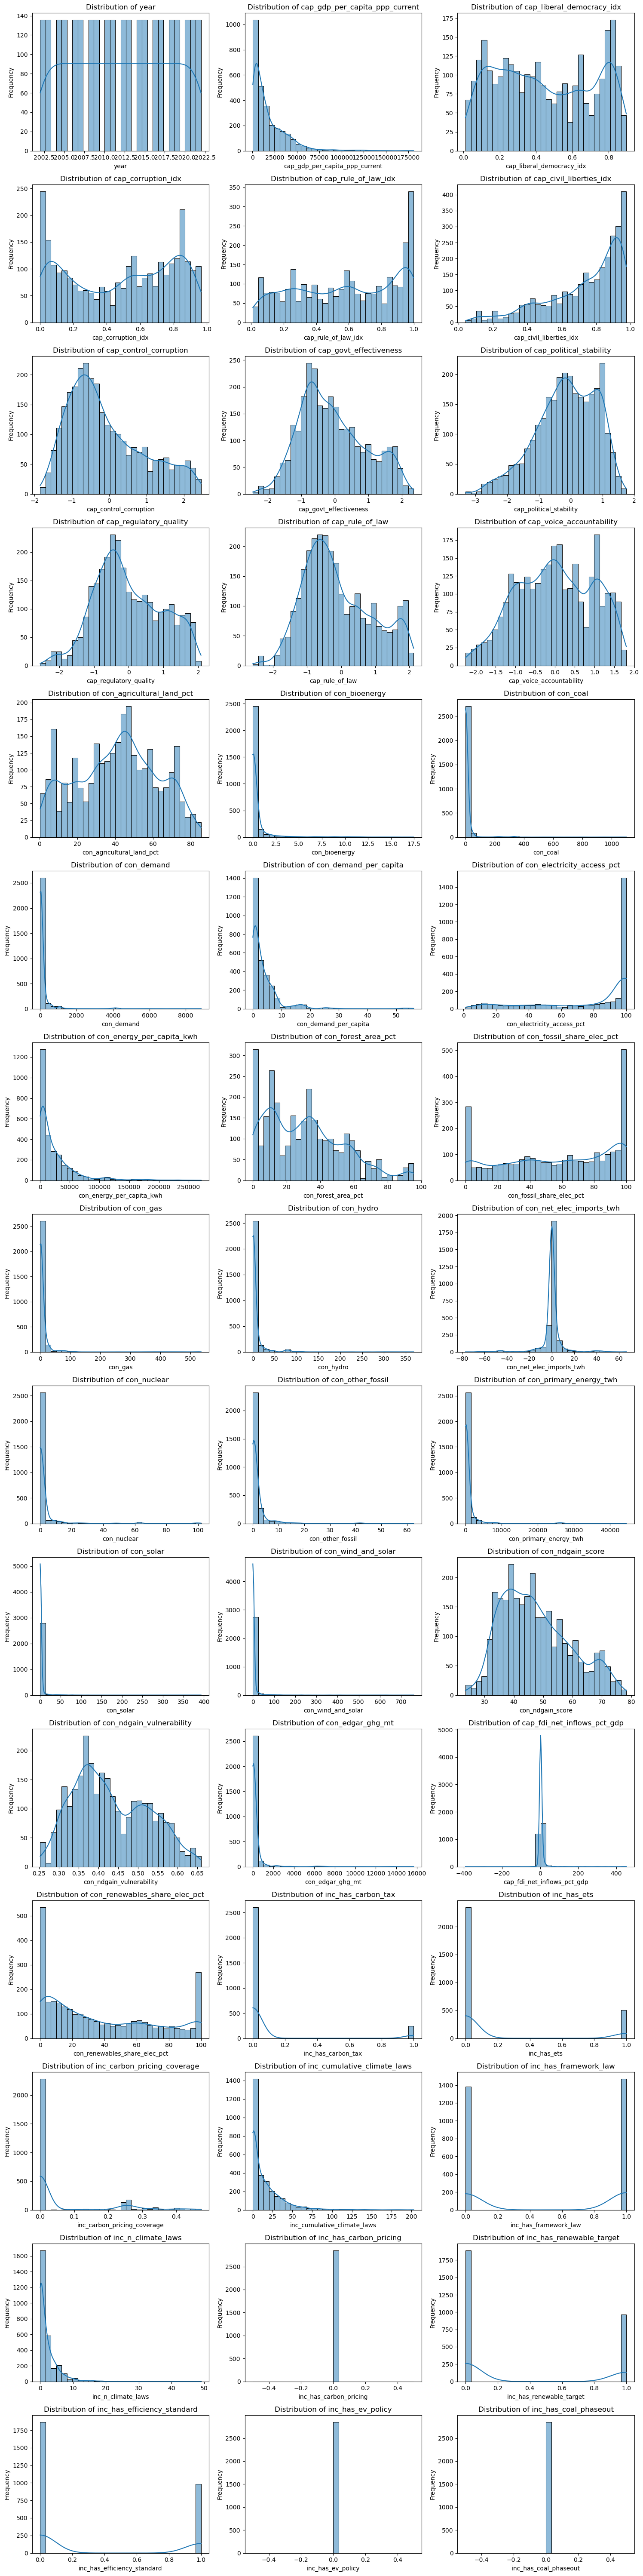

In [15]:
eda_utils.plot_numeric_fields_distributions(df_filtered)

In [16]:
df_filtered.describe()

,year,cap_gdp_per_capita_ppp_current,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,cap_civil_liberties_idx,cap_control_corruption,cap_govt_effectiveness,cap_political_stability,cap_regulatory_quality,...,inc_has_ets,inc_carbon_pricing_coverage,inc_cumulative_climate_laws,inc_has_framework_law,inc_n_climate_laws,inc_has_carbon_pricing,inc_has_renewable_target,inc_has_efficiency_standard,inc_has_ev_policy,inc_has_coal_phaseout
count,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,...,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.0,2856.000000,2856.000000,2856.0,2856.0
mean,2012.000000,17825.876908,0.447432,0.487975,0.575038,0.735454,-0.089537,-0.058090,-0.148709,-0.017408,...,0.176821,0.057448,14.716737,0.515406,2.184174,0.0,0.337535,0.345588,0.0,0.0
std,6.056361,20297.376882,0.262918,0.313468,0.308789,0.218340,1.015271,0.974984,0.951577,0.962821,...,0.381584,0.120404,21.349578,0.499850,3.496865,0.0,0.472952,0.475643,0.0,0.0
min,2002.000000,492.840755,0.012000,0.002000,0.010000,0.041000,-1.848734,-2.440229,-3.312951,-2.547726,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
25%,2007.000000,3590.244442,0.217000,0.170000,0.300500,0.608000,-0.853330,-0.784158,-0.749497,-0.709759,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
50%,2012.000000,10813.936025,0.421000,0.532000,0.592500,0.806000,-0.355056,-0.200911,-0.087762,-0.177335,...,0.000000,0.000000,7.000000,1.000000,1.000000,0.0,0.000000,0.000000,0.0,0.0
75%,2017.000000,25802.122340,0.688000,0.784000,0.871000,0.913000,0.564135,0.596476,0.625529,0.696511,...,0.000000,0.000000,22.000000,1.000000,3.000000,0.0,1.000000,1.000000,0.0,0.0
max,2022.000000,180939.439450,0.897000,0.965000,0.999000,0.976000,2.459118,2.347191,1.753184,2.081799,...,1.000000,0.473154,203.000000,1.000000,49.000000,0.0,1.000000,1.000000,0.0,0.0


In [17]:
# Identify full o zeros and drop them
zero_cols = df_filtered.columns[(df_filtered == 0).all()]
df_filtered = df_filtered.drop(columns=zero_cols)
print(zero_cols)


Index(['inc_has_carbon_pricing', 'inc_has_ev_policy', 'inc_has_coal_phaseout'], dtype='object')


In [18]:
# Identify binary columns
binary_cols = [
    c for c in df_filtered.columns
    if df_filtered[c].nunique(dropna=True) == 2
]
binary_cols

['inc_has_carbon_tax',
 'inc_has_ets',
 'inc_has_framework_law',
 'inc_has_renewable_target',
 'inc_has_efficiency_standard']

In [19]:
# Identify columns with low variance and with a lot of zeros

def get_zeros_and_variance_check_df(df):
    zeros_and_variance_check = []
    for field in df.select_dtypes(np.number):
        zero_share = (df[field] == 0).mean()
        field_var = df[field].var()

        if field in binary_cols:
            binary_flag = True
        else:
            binary_flag = False


        zeros_and_variance_check.append((field, zero_share, field_var, binary_flag))

    zeros_and_variance_check_df = pd.DataFrame(data=zeros_and_variance_check, columns=["field_name", "field_zero_share", "field_variance", "bianry_flag"])
    return zeros_and_variance_check_df

In [20]:
zeros_and_variance_check_df = get_zeros_and_variance_check_df(df_filtered)

In [21]:
# zeros_and_variance_check_df.to_clipboard(index=False)

In [22]:
skew = df_filtered[[col for col in df_filtered.columns if col not in binary_cols]].select_dtypes("number").skew().sort_values(ascending=False)
skew.head(20)

con_solar                         18.100333
con_wind_and_solar                16.703063
con_coal                          10.716587
con_gas                           10.058157
con_hydro                          8.669590
cap_fdi_net_inflows_pct_gdp        8.480725
con_edgar_ghg_mt                   8.467774
con_demand                         8.351667
con_primary_energy_twh             7.524785
con_nuclear                        6.399152
con_other_fossil                   6.160889
con_bioenergy                      5.676543
con_demand_per_capita              4.576735
inc_n_climate_laws                 4.486000
con_energy_per_capita_kwh          2.979298
inc_cumulative_climate_laws        2.726220
cap_gdp_per_capita_ppp_current     2.546681
inc_carbon_pricing_coverage        1.845223
cap_control_corruption             0.719912
con_forest_area_pct                0.669409
dtype: float64

In [23]:
skew.tail(10)

year                          0.000000
con_agricultural_land_pct    -0.079755
cap_voice_accountability     -0.111544
cap_corruption_idx           -0.148069
cap_rule_of_law_idx          -0.172612
con_fossil_share_elec_pct    -0.295079
cap_political_stability      -0.516479
con_net_elec_imports_twh     -0.981781
cap_civil_liberties_idx      -1.038481
con_electricity_access_pct   -1.156544
dtype: float64

In [24]:
highly_skewed_fields = skew[skew.abs() >= 1].index.to_list()
highly_skewed_fields

['con_solar',
 'con_wind_and_solar',
 'con_coal',
 'con_gas',
 'con_hydro',
 'cap_fdi_net_inflows_pct_gdp',
 'con_edgar_ghg_mt',
 'con_demand',
 'con_primary_energy_twh',
 'con_nuclear',
 'con_other_fossil',
 'con_bioenergy',
 'con_demand_per_capita',
 'inc_n_climate_laws',
 'con_energy_per_capita_kwh',
 'inc_cumulative_climate_laws',
 'cap_gdp_per_capita_ppp_current',
 'inc_carbon_pricing_coverage',
 'cap_civil_liberties_idx',
 'con_electricity_access_pct']

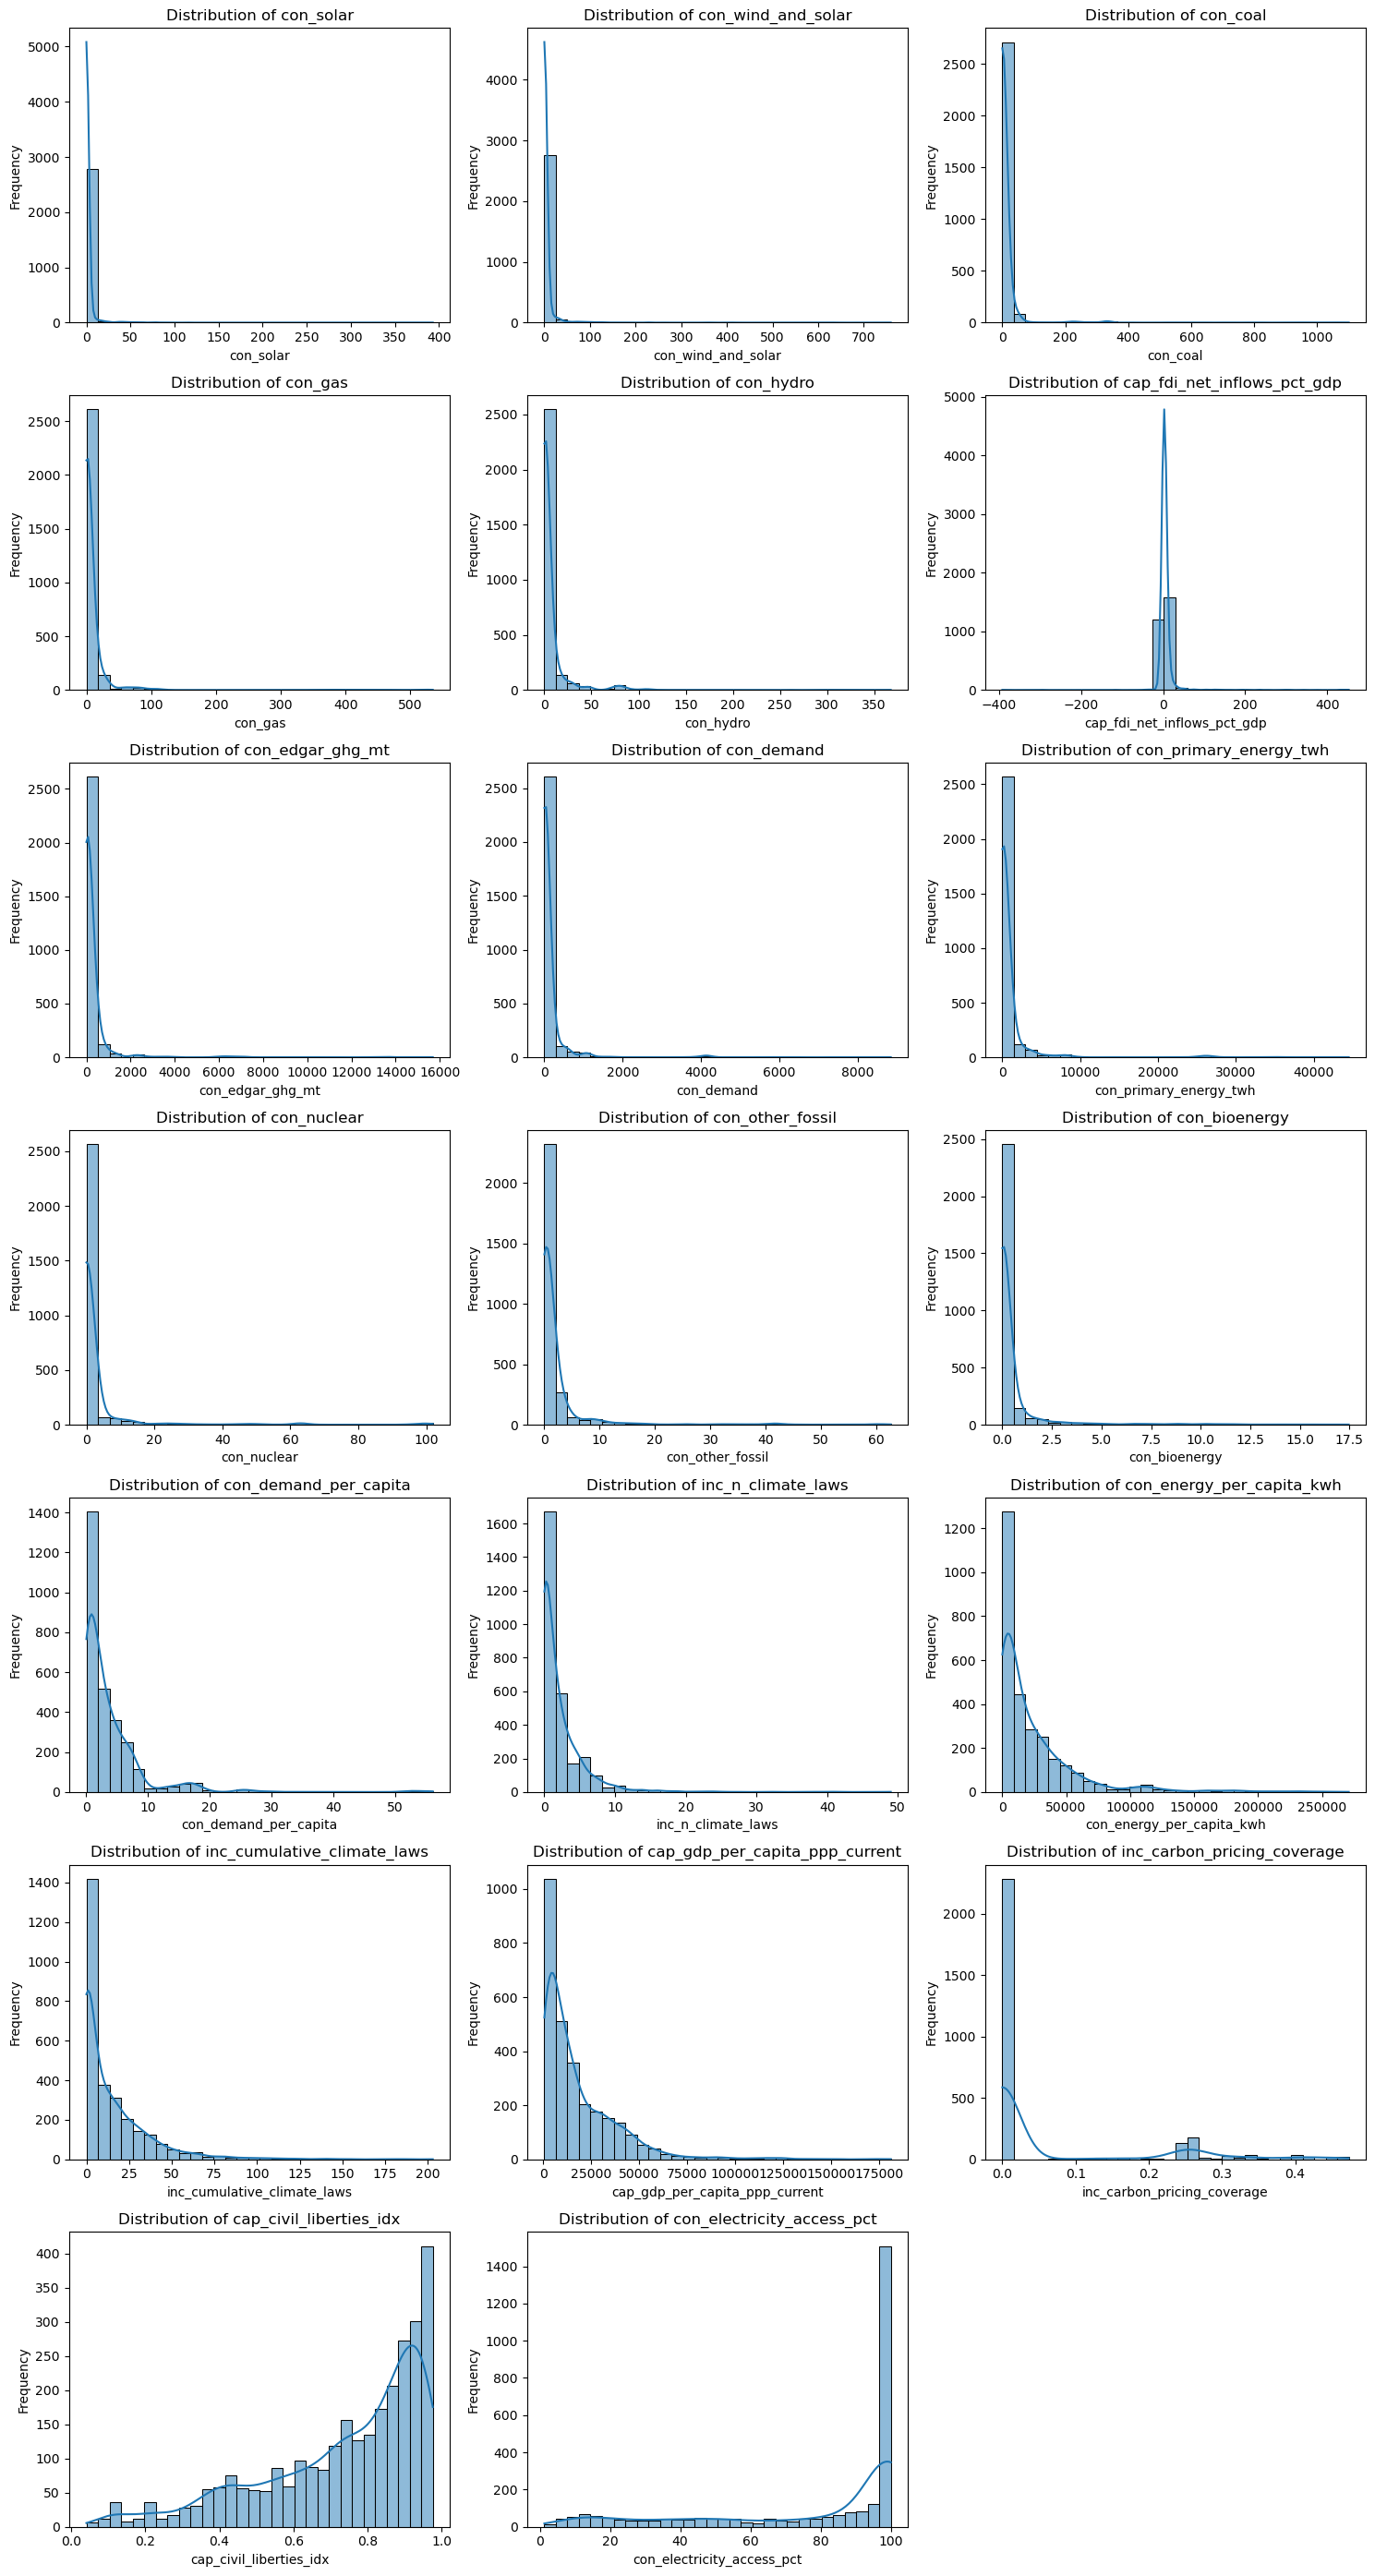

In [25]:
eda_utils.plot_numeric_fields_distributions(df_filtered[highly_skewed_fields])

In [26]:
# Log transform highly skewed fields
for field in highly_skewed_fields:
    df_filtered[f"x_log_signed_{field}"] = np.sign(df_filtered[field]) * np.log1p(np.abs(df_filtered[field]))
df_filtered.head()

,iso_alpha_3,year,cap_gdp_per_capita_ppp_current,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,cap_civil_liberties_idx,cap_control_corruption,cap_govt_effectiveness,cap_political_stability,...,x_log_signed_con_other_fossil,x_log_signed_con_bioenergy,x_log_signed_con_demand_per_capita,x_log_signed_inc_n_climate_laws,x_log_signed_con_energy_per_capita_kwh,x_log_signed_inc_cumulative_climate_laws,x_log_signed_cap_gdp_per_capita_ppp_current,x_log_signed_inc_carbon_pricing_coverage,x_log_signed_cap_civil_liberties_idx,x_log_signed_con_electricity_access_pct
0,AFG,2002,926.507941,0.084,0.919,0.137,0.523,-1.251137,-1.587687,-2.035034,...,0.029559,0.0,0.039221,0.0,5.054301,0.0,6.832501,0.0,0.420682,2.714695
1,AFG,2003,966.962032,0.086,0.919,0.129,0.550,-1.344180,-1.175768,-2.198372,...,0.039221,0.0,0.039221,0.0,5.167969,0.0,6.875193,0.0,0.438255,2.995732
2,AFG,2004,971.633503,0.091,0.931,0.123,0.546,-1.350647,-0.945146,-2.295682,...,0.048790,0.0,0.039221,0.0,5.067381,0.0,6.880007,0.0,0.435671,3.210844
3,AFG,2005,1076.087353,0.113,0.942,0.117,0.542,-1.447252,-1.228816,-2.067510,...,0.048790,0.0,0.039221,0.0,5.330145,0.0,6.982016,0.0,0.433080,3.391147
4,AFG,2006,1121.834471,0.199,0.955,0.116,0.540,-1.446292,-1.473652,-2.219135,...,0.048790,0.0,0.048790,0.0,5.552444,0.0,7.023612,0.0,0.431782,3.540959


In [27]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2856 entries, 0 to 2855
Data columns (total 63 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   iso_alpha_3                                  2856 non-null   object 
 1   year                                         2856 non-null   int64  
 2   cap_gdp_per_capita_ppp_current               2856 non-null   float64
 3   cap_liberal_democracy_idx                    2856 non-null   float64
 4   cap_corruption_idx                           2856 non-null   float64
 5   cap_rule_of_law_idx                          2856 non-null   float64
 6   cap_civil_liberties_idx                      2856 non-null   float64
 7   cap_control_corruption                       2856 non-null   float64
 8   cap_govt_effectiveness                       2856 non-null   float64
 9   cap_political_stability                      2856 non-null   float64
 10  

In [28]:
# Drop the skewed fields since we have the log transform version
df_log_transformed = df_filtered.drop(columns=highly_skewed_fields)

In [29]:
skew_after_log_transform = df_log_transformed[[col for col in df_log_transformed.columns if col not in binary_cols]].select_dtypes("number").skew().sort_values(ascending=False)
skew_after_log_transform.head(20)

x_log_signed_con_solar                      4.072531
x_log_signed_con_bioenergy                  3.204910
x_log_signed_con_wind_and_solar             2.861822
x_log_signed_con_nuclear                    2.769048
x_log_signed_con_coal                       2.328500
x_log_signed_con_other_fossil               1.994020
x_log_signed_inc_carbon_pricing_coverage    1.766301
x_log_signed_con_hydro                      1.589147
x_log_signed_con_gas                        1.486547
cap_control_corruption                      0.719912
con_forest_area_pct                         0.669409
x_log_signed_con_demand                     0.665992
x_log_signed_inc_n_climate_laws             0.635581
con_renewables_share_elec_pct               0.587148
x_log_signed_con_demand_per_capita          0.535643
con_ndgain_score                            0.527854
x_log_signed_con_edgar_ghg_mt               0.493132
cap_rule_of_law                             0.454741
cap_govt_effectiveness                      0.

In [30]:
zeros_and_variance_check_df_after_transformation = get_zeros_and_variance_check_df(df_log_transformed)
zeros_and_variance_check_df_after_transformation.head()

,field_name,field_zero_share,field_variance,bianry_flag
0,year,0.0,36.679510,False
1,cap_liberal_democracy_idx,0.0,0.069126,False
2,cap_corruption_idx,0.0,0.098262,False
3,cap_rule_of_law_idx,0.0,0.095350,False
4,cap_control_corruption,0.0,1.030776,False


In [31]:
# zeros_and_variance_check_df_after_transformation.to_clipboard()

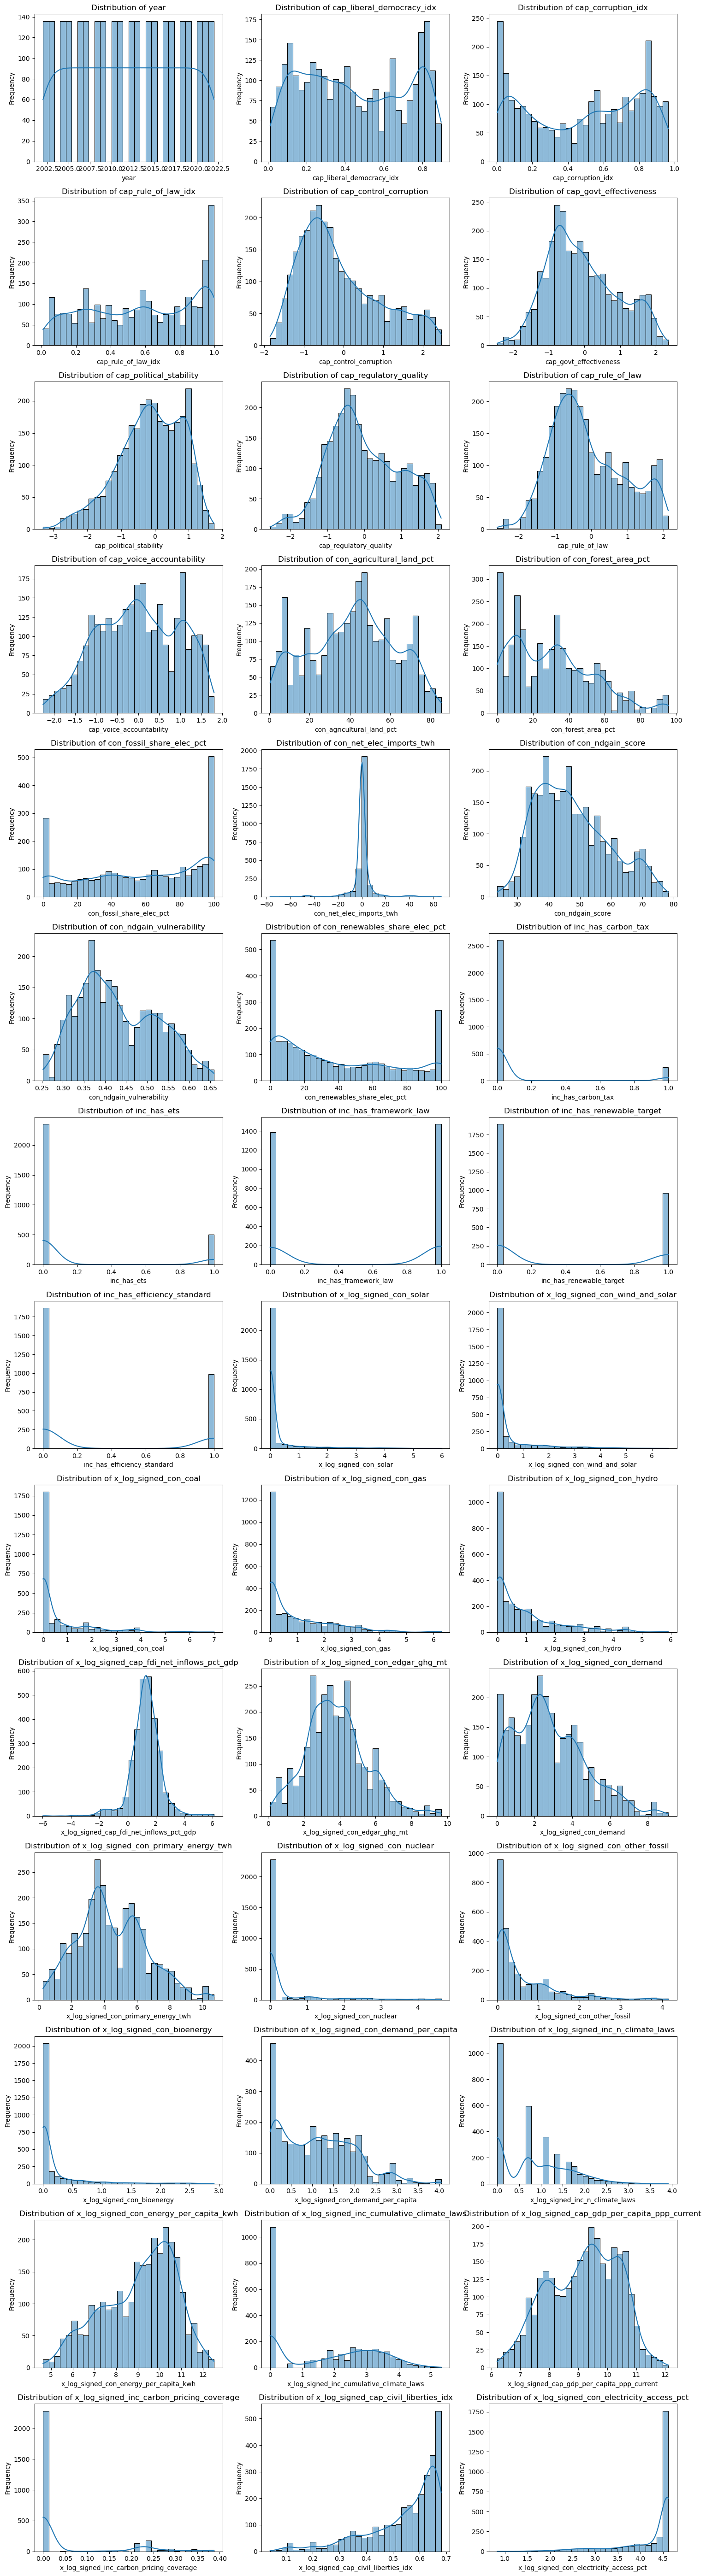

In [32]:
eda_utils.plot_numeric_fields_distributions(df_log_transformed)

In [33]:
df_log_transformed.columns

Index(['iso_alpha_3', 'year', 'cap_liberal_democracy_idx',
       'cap_corruption_idx', 'cap_rule_of_law_idx', 'cap_control_corruption',
       'cap_govt_effectiveness', 'cap_political_stability',
       'cap_regulatory_quality', 'cap_rule_of_law', 'cap_voice_accountability',
       'con_agricultural_land_pct', 'con_forest_area_pct',
       'con_fossil_share_elec_pct', 'con_net_elec_imports_twh',
       'con_ndgain_score', 'con_ndgain_vulnerability',
       'con_renewables_share_elec_pct', 'inc_has_carbon_tax', 'inc_has_ets',
       'inc_has_framework_law', 'inc_has_renewable_target',
       'inc_has_efficiency_standard', 'x_log_signed_con_solar',
       'x_log_signed_con_wind_and_solar', 'x_log_signed_con_coal',
       'x_log_signed_con_gas', 'x_log_signed_con_hydro',
       'x_log_signed_cap_fdi_net_inflows_pct_gdp',
       'x_log_signed_con_edgar_ghg_mt', 'x_log_signed_con_demand',
       'x_log_signed_con_primary_energy_twh', 'x_log_signed_con_nuclear',
       'x_log_signed_con_oth

## PCA

In [34]:
X = df_log_transformed.select_dtypes(include="number").drop(columns=["year", "x_log_signed_con_edgar_ghg_mt"])
X.head()

,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,cap_control_corruption,cap_govt_effectiveness,cap_political_stability,cap_regulatory_quality,cap_rule_of_law,cap_voice_accountability,con_agricultural_land_pct,...,x_log_signed_con_other_fossil,x_log_signed_con_bioenergy,x_log_signed_con_demand_per_capita,x_log_signed_inc_n_climate_laws,x_log_signed_con_energy_per_capita_kwh,x_log_signed_inc_cumulative_climate_laws,x_log_signed_cap_gdp_per_capita_ppp_current,x_log_signed_inc_carbon_pricing_coverage,x_log_signed_cap_civil_liberties_idx,x_log_signed_con_electricity_access_pct
0,0.084,0.919,0.137,-1.251137,-1.587687,-2.035034,-1.811546,-1.673473,-1.433421,57.939684,...,0.029559,0.0,0.039221,0.0,5.054301,0.0,6.832501,0.0,0.420682,2.714695
1,0.086,0.919,0.129,-1.344180,-1.175768,-2.198372,-1.463108,-1.558294,-1.177571,58.083805,...,0.039221,0.0,0.039221,0.0,5.167969,0.0,6.875193,0.0,0.438255,2.995732
2,0.091,0.931,0.123,-1.350647,-0.945146,-2.295682,-1.511549,-1.693925,-1.203034,58.151266,...,0.048790,0.0,0.039221,0.0,5.067381,0.0,6.880007,0.0,0.435671,3.210844
3,0.113,0.942,0.117,-1.447252,-1.228816,-2.067510,-1.643440,-1.662966,-1.125430,58.134400,...,0.048790,0.0,0.039221,0.0,5.330145,0.0,6.982016,0.0,0.433080,3.391147
4,0.199,0.955,0.116,-1.446292,-1.473652,-2.219135,-1.689469,-1.879005,-1.110294,58.123668,...,0.048790,0.0,0.048790,0.0,5.552444,0.0,7.023612,0.0,0.431782,3.540959


In [35]:
X_scaled = StandardScaler().fit_transform(X)
X_scaled

array([[-1.38254455,  1.3752642 , -1.41881707, ..., -0.48204148,
        -0.88728111, -2.25849703],
       [-1.37493628,  1.3752642 , -1.4447293 , ..., -0.48204148,
        -0.75918582, -1.83750083],
       [-1.35591561,  1.41355238, -1.46416347, ..., -0.48204148,
        -0.77802144, -1.51526247],
       ...,
       [-0.971698  ,  0.97961968, -1.10787031, ..., -0.48204148,
        -1.41828412, -0.35794814],
       [-0.98691454,  1.07853081, -1.16617283, ..., -0.48204148,
        -1.55337279, -0.46489086],
       [-1.01734762,  1.01471718, -1.185607  , ..., -0.48204148,
        -1.55337279, -0.43229199]], shape=(2856, 40))

In [36]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
X_pca

array([[-6.71599013,  1.05517398,  1.19844883, ...,  0.30773697,
         0.36196579, -0.82159638],
       [-6.29408397,  1.07616551,  0.8406778 , ...,  0.14320637,
         0.47838391, -1.06957902],
       [-6.3149444 ,  0.99515565,  0.79554981, ...,  0.14547858,
         0.39341307, -1.18050321],
       ...,
       [-3.92581776,  1.59891527,  1.67844339, ..., -0.27557596,
        -0.37770073, -0.23469972],
       [-3.52883465,  2.14348217,  2.10093971, ..., -0.16906277,
         0.32427403, -0.49796218],
       [-3.46530811,  1.94841394,  1.91905847, ..., -0.26686085,
         0.01658159, -0.45839425]], shape=(2856, 19))

In [37]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

In [38]:
loadings.sort_values("PC1", key=abs, ascending=False).to_clipboard()


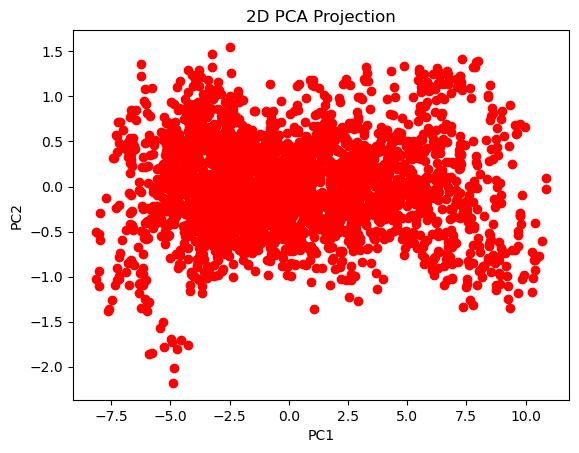

In [39]:
plt.scatter(X_pca[:, 0], X_pca[:, 18], c='red')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA Projection')
plt.show()

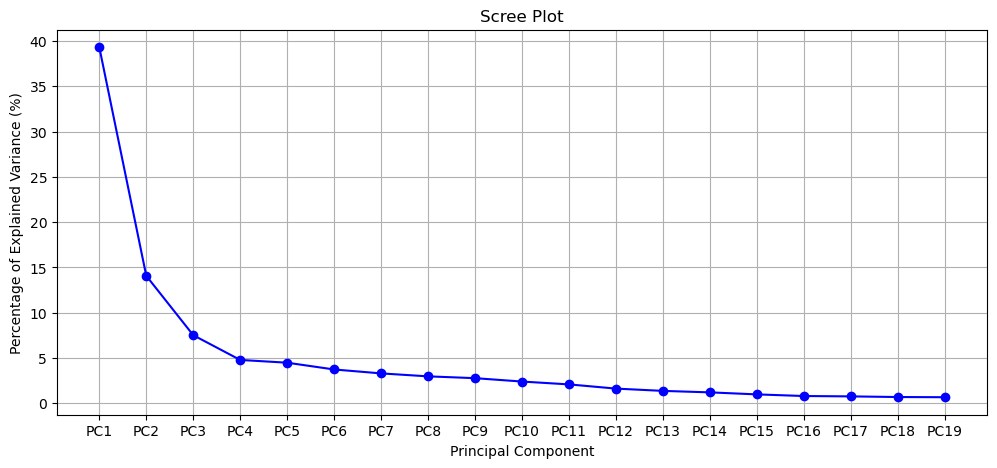

In [40]:
# 1. Get the proportion of variance explained by each component
exp_var_pct = pca.explained_variance_ratio_ * 100
pc_labels = [f"PC{i+1}" for i in range(len(exp_var_pct))]

# 2. Plotting
plt.figure(figsize=(12, 5))
plt.plot(pc_labels, exp_var_pct, marker='o', linestyle='-', color='b')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Percentage of Explained Variance (%)')
plt.grid(True)
plt.show()

In [41]:
df_log_transformed.shape

(2856, 43)

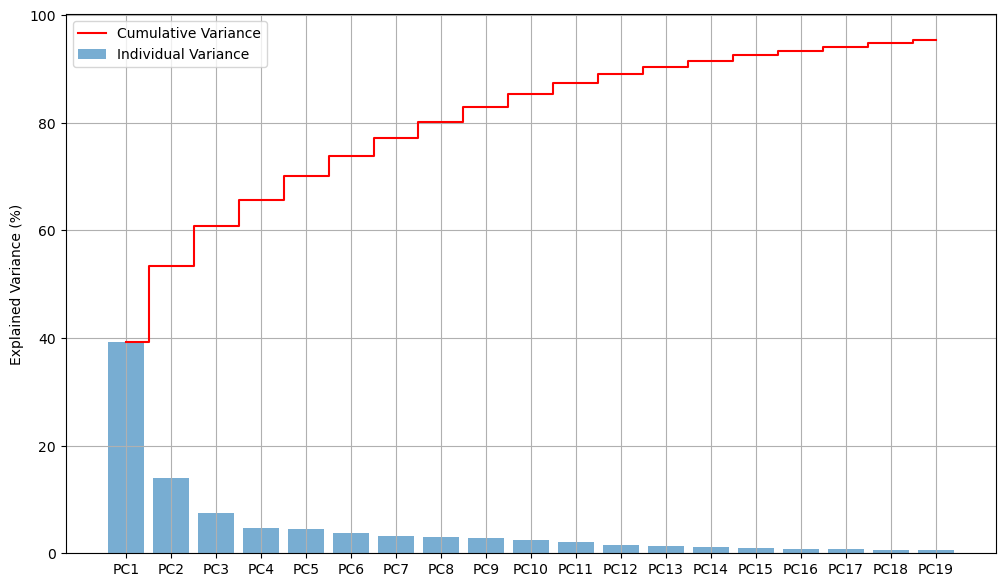

In [42]:
cum_var = np.cumsum(pca.explained_variance_ratio_) * 100

plt.figure(figsize=(12, 7))
plt.bar(pc_labels, exp_var_pct, alpha=0.6, label='Individual Variance')
plt.step(pc_labels, cum_var, where='mid', label='Cumulative Variance', color='red')
plt.ylabel('Explained Variance (%)')
plt.legend(loc='best')
plt.grid()
plt.show()

In [43]:
def get_top_features_per_PC(loadings_df, top_n=10):

    df = (
        loadings_df
        .copy()
        .assign(feature_name=lambda x: x.index)
        .reset_index(drop=True)
    )

    results = []

    pc_cols = [c for c in df.columns if c.startswith("PC")]

    for pc in pc_cols:

        temp = (
            df[["feature_name", pc]]
            .assign(abs_loading=lambda x: x[pc].abs())
            .sort_values("abs_loading", ascending=False)
            .head(top_n)
            .assign(
                principal_component=pc,
                loading=lambda x: x[pc]      # <-- KEY FIX
            )
            [["feature_name", "principal_component", "loading", "abs_loading"]]
        )

        results.append(temp)

    return pd.concat(results, ignore_index=True)


In [44]:
loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19
cap_liberal_democracy_idx,0.199720,-0.159124,0.107064,-0.098159,0.113534,-0.141627,-0.033718,0.039475,0.074480,0.009808,0.244069,-0.016184,0.021699,-0.134530,-0.082728,-0.002572,0.042218,-0.041804,0.014872
cap_corruption_idx,-0.202509,0.170035,-0.039374,0.066819,-0.045823,0.122348,-0.016245,0.022144,0.025189,0.101793,0.108275,-0.085866,0.035426,0.055213,0.087866,0.325330,0.214518,0.200771,0.159167
cap_rule_of_law_idx,0.198946,-0.182739,0.086483,-0.084533,0.085888,-0.187594,-0.025760,-0.009262,0.026968,-0.069640,0.060205,0.070935,-0.029355,-0.120933,-0.117228,-0.199970,-0.108864,-0.083416,-0.078165
cap_control_corruption,0.211431,-0.160254,0.024180,-0.067798,0.049968,-0.047632,-0.078311,-0.036674,-0.025104,-0.107117,-0.225751,0.137715,0.005678,0.074324,0.021102,0.011024,-0.162360,-0.134089,-0.108139
cap_govt_effectiveness,0.226854,-0.121776,-0.018442,-0.037901,0.020000,-0.026786,-0.080923,-0.038931,-0.018118,-0.048190,-0.134752,0.112628,-0.035963,0.068069,0.032576,0.022725,-0.133432,-0.002832,-0.031598


In [45]:
top_features_per_PC_df = get_top_features_per_PC(loadings, top_n=5)
top_features_per_PC_df.head(50)

,feature_name,principal_component,loading,abs_loading
0,con_ndgain_score,PC1,0.233937,0.233937
1,cap_govt_effectiveness,PC1,0.226854,0.226854
2,cap_rule_of_law,PC1,0.221232,0.221232
3,cap_regulatory_quality,PC1,0.219995,0.219995
4,x_log_signed_con_demand_per_capita,PC1,0.215118,0.215118
5,x_log_signed_con_gas,PC2,0.271322,0.271322
6,x_log_signed_con_coal,PC2,0.255953,0.255953
7,x_log_signed_con_demand,PC2,0.243818,0.243818
8,x_log_signed_con_hydro,PC2,0.241029,0.241029
9,x_log_signed_con_primary_energy_twh,PC2,0.236933,0.236933


In [46]:
top_features_per_PC_df.to_clipboard(index=False)

In [47]:
# Get the unique set of features
top_features_PCA = top_features_per_PC_df.feature_name.unique()
top_features_PCA

array(['con_ndgain_score', 'cap_govt_effectiveness', 'cap_rule_of_law',
       'cap_regulatory_quality', 'x_log_signed_con_demand_per_capita',
       'x_log_signed_con_gas', 'x_log_signed_con_coal',
       'x_log_signed_con_demand', 'x_log_signed_con_hydro',
       'x_log_signed_con_primary_energy_twh',
       'con_renewables_share_elec_pct', 'con_fossil_share_elec_pct',
       'x_log_signed_inc_cumulative_climate_laws',
       'x_log_signed_inc_n_climate_laws', 'inc_has_framework_law',
       'x_log_signed_con_electricity_access_pct',
       'x_log_signed_con_nuclear', 'con_agricultural_land_pct',
       'con_forest_area_pct', 'x_log_signed_inc_carbon_pricing_coverage',
       'inc_has_ets', 'inc_has_carbon_tax',
       'x_log_signed_cap_civil_liberties_idx', 'con_net_elec_imports_twh',
       'inc_has_renewable_target', 'inc_has_efficiency_standard',
       'x_log_signed_con_solar',
       'x_log_signed_cap_fdi_net_inflows_pct_gdp',
       'x_log_signed_con_other_fossil', 'cap_libera

## ML

In [48]:
training_df = df_log_transformed.sort_values(by=["iso_alpha_3", "year"]).reset_index(drop=True)
training_df.head()

,iso_alpha_3,year,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,cap_control_corruption,cap_govt_effectiveness,cap_political_stability,cap_regulatory_quality,cap_rule_of_law,...,x_log_signed_con_other_fossil,x_log_signed_con_bioenergy,x_log_signed_con_demand_per_capita,x_log_signed_inc_n_climate_laws,x_log_signed_con_energy_per_capita_kwh,x_log_signed_inc_cumulative_climate_laws,x_log_signed_cap_gdp_per_capita_ppp_current,x_log_signed_inc_carbon_pricing_coverage,x_log_signed_cap_civil_liberties_idx,x_log_signed_con_electricity_access_pct
0,AFG,2002,0.084,0.919,0.137,-1.251137,-1.587687,-2.035034,-1.811546,-1.673473,...,0.029559,0.0,0.039221,0.0,5.054301,0.0,6.832501,0.0,0.420682,2.714695
1,AFG,2003,0.086,0.919,0.129,-1.344180,-1.175768,-2.198372,-1.463108,-1.558294,...,0.039221,0.0,0.039221,0.0,5.167969,0.0,6.875193,0.0,0.438255,2.995732
2,AFG,2004,0.091,0.931,0.123,-1.350647,-0.945146,-2.295682,-1.511549,-1.693925,...,0.048790,0.0,0.039221,0.0,5.067381,0.0,6.880007,0.0,0.435671,3.210844
3,AFG,2005,0.113,0.942,0.117,-1.447252,-1.228816,-2.067510,-1.643440,-1.662966,...,0.048790,0.0,0.039221,0.0,5.330145,0.0,6.982016,0.0,0.433080,3.391147
4,AFG,2006,0.199,0.955,0.116,-1.446292,-1.473652,-2.219135,-1.689469,-1.879005,...,0.048790,0.0,0.048790,0.0,5.552444,0.0,7.023612,0.0,0.431782,3.540959


In [49]:
training_df.year.max()

np.int64(2022)

In [50]:
target_var = "x_log_signed_con_edgar_ghg_mt"

In [51]:
# features = [col for col in training_df.columns if col not in ["iso_alpha_3", "year", target_var]]
# features

In [52]:
# # Check country errors
# country_erros_best_preds = ra.per_country_errors(model="ElasticNet")
# country_erros_best_preds.sort_values(by="mae_level", ascending=False).head(10)

In [53]:
# ra_coef_table = ra.get_enet_coef_table()
# ra_coef_table.head()

In [54]:
# ra.plot_top_enet_regressors(n=10, figsize=(10,5))

### Train the model with reduced set of features informed by ablation experiment

In [55]:
top_features_ablation = [
        'x_log_signed_con_solar', 
        'inc_has_efficiency_standard',
        'inc_has_renewable_target', 
        'con_net_elec_imports_twh',
        'x_log_signed_cap_civil_liberties_idx', 
        'inc_has_carbon_tax',
        'inc_has_ets',
        'x_log_signed_inc_carbon_pricing_coverage',
        'con_forest_area_pct',
        'con_agricultural_land_pct',
        'x_log_signed_con_nuclear',
        'x_log_signed_con_electricity_access_pct', 
        'inc_has_framework_law',
        'x_log_signed_inc_n_climate_laws',
        'x_log_signed_inc_cumulative_climate_laws',
        'con_fossil_share_elec_pct', 
        'con_renewables_share_elec_pct',
        'x_log_signed_con_primary_energy_twh',
        'x_log_signed_con_hydro',
        'x_log_signed_con_demand',
        'x_log_signed_con_coal',
        'x_log_signed_con_gas',
        'x_log_signed_con_demand_per_capita',
        'cap_regulatory_quality',
        'cap_rule_of_law',
        'cap_govt_effectiveness',
        'con_ndgain_score'
        ]


In [56]:
columns_to_filter = ["iso_alpha_3", "year", target_var] + top_features_ablation
columns_to_filter

['iso_alpha_3',
 'year',
 'x_log_signed_con_edgar_ghg_mt',
 'x_log_signed_con_solar',
 'inc_has_efficiency_standard',
 'inc_has_renewable_target',
 'con_net_elec_imports_twh',
 'x_log_signed_cap_civil_liberties_idx',
 'inc_has_carbon_tax',
 'inc_has_ets',
 'x_log_signed_inc_carbon_pricing_coverage',
 'con_forest_area_pct',
 'con_agricultural_land_pct',
 'x_log_signed_con_nuclear',
 'x_log_signed_con_electricity_access_pct',
 'inc_has_framework_law',
 'x_log_signed_inc_n_climate_laws',
 'x_log_signed_inc_cumulative_climate_laws',
 'con_fossil_share_elec_pct',
 'con_renewables_share_elec_pct',
 'x_log_signed_con_primary_energy_twh',
 'x_log_signed_con_hydro',
 'x_log_signed_con_demand',
 'x_log_signed_con_coal',
 'x_log_signed_con_gas',
 'x_log_signed_con_demand_per_capita',
 'cap_regulatory_quality',
 'cap_rule_of_law',
 'cap_govt_effectiveness',
 'con_ndgain_score']

In [57]:
training_df_after_ablation = training_df[columns_to_filter]
training_df_after_ablation.head()

,iso_alpha_3,year,x_log_signed_con_edgar_ghg_mt,x_log_signed_con_solar,inc_has_efficiency_standard,inc_has_renewable_target,con_net_elec_imports_twh,x_log_signed_cap_civil_liberties_idx,inc_has_carbon_tax,inc_has_ets,...,x_log_signed_con_primary_energy_twh,x_log_signed_con_hydro,x_log_signed_con_demand,x_log_signed_con_coal,x_log_signed_con_gas,x_log_signed_con_demand_per_capita,cap_regulatory_quality,cap_rule_of_law,cap_govt_effectiveness,con_ndgain_score
0,AFG,2002,2.892853,0.0,0.0,0.0,0.10,0.420682,0.0,0.0,...,1.465106,0.173953,0.593327,1.891605,0.0,0.039221,-1.811546,-1.673473,-1.587687,35.335123
1,AFG,2003,2.930250,0.0,0.0,0.0,0.10,0.438255,0.0,0.0,...,1.603017,0.173953,0.698135,2.387845,0.0,0.039221,-1.463108,-1.558294,-1.175768,35.542042
2,AFG,2004,2.933296,0.0,0.0,0.0,0.10,0.435671,0.0,0.0,...,1.551173,0.173953,0.636577,2.150599,0.0,0.039221,-1.511549,-1.693925,-0.945146,35.409770
3,AFG,2005,2.954458,0.0,0.0,0.0,0.10,0.433080,0.0,0.0,...,1.794090,0.173953,0.652325,2.118662,0.0,0.039221,-1.643440,-1.662966,-1.228816,32.098198
4,AFG,2006,2.968414,0.0,0.0,0.0,0.43,0.431782,0.0,0.0,...,2.019028,0.182322,0.845868,2.871868,0.0,0.048790,-1.689469,-1.879005,-1.473652,30.590486


In [58]:
training_df_after_ablation.columns

Index(['iso_alpha_3', 'year', 'x_log_signed_con_edgar_ghg_mt',
       'x_log_signed_con_solar', 'inc_has_efficiency_standard',
       'inc_has_renewable_target', 'con_net_elec_imports_twh',
       'x_log_signed_cap_civil_liberties_idx', 'inc_has_carbon_tax',
       'inc_has_ets', 'x_log_signed_inc_carbon_pricing_coverage',
       'con_forest_area_pct', 'con_agricultural_land_pct',
       'x_log_signed_con_nuclear', 'x_log_signed_con_electricity_access_pct',
       'inc_has_framework_law', 'x_log_signed_inc_n_climate_laws',
       'x_log_signed_inc_cumulative_climate_laws', 'con_fossil_share_elec_pct',
       'con_renewables_share_elec_pct', 'x_log_signed_con_primary_energy_twh',
       'x_log_signed_con_hydro', 'x_log_signed_con_demand',
       'x_log_signed_con_coal', 'x_log_signed_con_gas',
       'x_log_signed_con_demand_per_capita', 'cap_regulatory_quality',
       'cap_rule_of_law', 'cap_govt_effectiveness', 'con_ndgain_score'],
      dtype='object')

In [59]:
training_df_after_ablation = training_df_after_ablation.sort_values(["iso_alpha_3", "year"]).copy()

# # ================================
# # 1. 1-year lag of emissions (no leakage)
# # ================================

# training_df_after_ablation["em_lag_1y"] = (
#     training_df_after_ablation
#     .groupby("iso_alpha_3")["x_log_signed_con_edgar_ghg_mt"]
#     .shift(1)
# )

# ================================
# Helper function to compute slope
# ================================

def compute_slope(series):
    x = np.arange(len(series))
    y = series.values
    return np.polyfit(x, y, 1)[0]


# ================================
# 2. 3-year rolling trend
# ================================

training_df_after_ablation["em_trend_3y"] = (
    training_df_after_ablation
    .groupby("iso_alpha_3")["x_log_signed_con_edgar_ghg_mt"]
    .rolling(window=3, min_periods=2)
    .apply(compute_slope, raw=False)
    .reset_index(level=0, drop=True)
)

# shift to avoid leakage
training_df_after_ablation["em_trend_3y"] = (
    training_df_after_ablation
    .groupby("iso_alpha_3")["em_trend_3y"]
    .shift(1)
)


# ================================
# 3. 5-year rolling trend
# ================================

training_df_after_ablation["em_trend_5y"] = (
    training_df_after_ablation
    .groupby("iso_alpha_3")["x_log_signed_con_edgar_ghg_mt"]
    .rolling(window=5, min_periods=3)
    .apply(compute_slope, raw=False)
    .reset_index(level=0, drop=True)
)

# shift to avoid leakage
training_df_after_ablation["em_trend_5y"] = (
    training_df_after_ablation
    .groupby("iso_alpha_3")["em_trend_5y"]
    .shift(1)
)


# ================================
# 4. Trend acceleration
# ================================

training_df_after_ablation["em_acceleration"] = (
    training_df_after_ablation["em_trend_3y"] -
    training_df_after_ablation["em_trend_5y"]
)


# ================================
# 5. Rolling volatility (5y std)
# ================================

training_df_after_ablation["em_volatility_5y"] = (
    training_df_after_ablation
    .groupby("iso_alpha_3")["x_log_signed_con_edgar_ghg_mt"]
    .rolling(window=5, min_periods=3)
    .std()
    .reset_index(level=0, drop=True)
)

# shift to avoid leakage
training_df_after_ablation["em_volatility_5y"] = (
    training_df_after_ablation
    .groupby("iso_alpha_3")["em_volatility_5y"]
    .shift(1)
)

In [60]:
training_df_after_ablation = training_df_after_ablation.dropna()
training_df_after_ablation

,iso_alpha_3,year,x_log_signed_con_edgar_ghg_mt,x_log_signed_con_solar,inc_has_efficiency_standard,inc_has_renewable_target,con_net_elec_imports_twh,x_log_signed_cap_civil_liberties_idx,inc_has_carbon_tax,inc_has_ets,...,x_log_signed_con_gas,x_log_signed_con_demand_per_capita,cap_regulatory_quality,cap_rule_of_law,cap_govt_effectiveness,con_ndgain_score,em_trend_3y,em_trend_5y,em_acceleration,em_volatility_5y
3,AFG,2005,2.954458,0.000000,0.0,0.0,0.10,0.433080,0.0,0.0,...,0.0,0.039221,-1.643440,-1.662966,-1.228816,32.098198,0.020222,0.020222,0.000000,0.022522
4,AFG,2006,2.968414,0.000000,0.0,0.0,0.43,0.431782,0.0,0.0,...,0.0,0.048790,-1.689469,-1.879005,-1.473652,30.590486,0.012104,0.018786,-0.006682,0.025614
5,AFG,2007,3.026143,0.000000,0.0,0.0,0.61,0.433080,0.0,0.0,...,0.0,0.058269,-1.708872,-1.852560,-1.440111,30.163952,0.017559,0.017533,0.000026,0.028694
6,AFG,2008,3.181789,0.000000,0.0,0.0,0.75,0.433080,0.0,0.0,...,0.0,0.058269,-1.607167,-1.903308,-1.527795,29.877764,0.035842,0.022690,0.013152,0.038868
7,AFG,2009,3.307380,0.000000,0.0,0.0,1.15,0.435024,0.0,0.0,...,0.0,0.067659,-1.664508,-1.876119,-1.507752,30.253636,0.106687,0.056867,0.049820,0.100536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2851,ZWE,2018,3.474243,0.009950,0.0,0.0,1.02,0.347836,0.0,0.0,...,0.0,0.530628,-1.525652,-1.293059,-1.297955,32.965235,-0.038810,-0.026694,-0.012115,0.047119
2852,ZWE,2019,3.440653,0.009950,0.0,0.0,1.11,0.330742,0.0,0.0,...,0.0,0.488580,-1.486515,-1.311041,-1.310435,33.217883,0.025367,-0.004123,0.029490,0.033050
2853,ZWE,2020,3.379005,0.009950,0.0,0.0,1.98,0.347836,0.0,0.0,...,0.0,0.444686,-1.434415,-1.337362,-1.342368,33.229297,0.016821,-0.003722,0.020543,0.032957
2854,ZWE,2021,3.418558,0.029559,1.0,1.0,1.74,0.329304,0.0,0.0,...,0.0,0.500775,-1.386109,-1.282122,-1.290561,33.581333,-0.047619,-0.005536,-0.042082,0.035746


In [61]:
features_list = training_df_after_ablation.columns[
    ~training_df_after_ablation.columns.isin(["iso_alpha_3", "year", target_var])
].tolist()

features_list

['x_log_signed_con_solar',
 'inc_has_efficiency_standard',
 'inc_has_renewable_target',
 'con_net_elec_imports_twh',
 'x_log_signed_cap_civil_liberties_idx',
 'inc_has_carbon_tax',
 'inc_has_ets',
 'x_log_signed_inc_carbon_pricing_coverage',
 'con_forest_area_pct',
 'con_agricultural_land_pct',
 'x_log_signed_con_nuclear',
 'x_log_signed_con_electricity_access_pct',
 'inc_has_framework_law',
 'x_log_signed_inc_n_climate_laws',
 'x_log_signed_inc_cumulative_climate_laws',
 'con_fossil_share_elec_pct',
 'con_renewables_share_elec_pct',
 'x_log_signed_con_primary_energy_twh',
 'x_log_signed_con_hydro',
 'x_log_signed_con_demand',
 'x_log_signed_con_coal',
 'x_log_signed_con_gas',
 'x_log_signed_con_demand_per_capita',
 'cap_regulatory_quality',
 'cap_rule_of_law',
 'cap_govt_effectiveness',
 'con_ndgain_score',
 'em_trend_3y',
 'em_trend_5y',
 'em_acceleration',
 'em_volatility_5y']

In [62]:
print("Running regression without group feature...")

enet_params = dict(
    l1_ratio=[0.01],
    n_alphas=300,          # wider alpha search
    eps=1e-4,              # allow smaller alphas
    cv=7,
    max_iter=30000,
    n_jobs=1,
    random_state=42,
)


ra_4 = RegressionAnalysis(
    df=training_df_after_ablation,
    target_col=target_var,
    group_col="iso_alpha_3",
    year_col="year",
    holdout_years=5,
    scaler_type="standard",
    feature_cols=features_list,
    include_year=False,
    enet_params=enet_params
)

ra_4.cross_validate()
ra_4.fit()
ra_4.evaluate()

Running regression without group feature...

Cross-validation results:
------------------------------------------------------------------------------------------
Model               Time MAE    Group MAE


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_desc

ElasticNet            0.2226          nan
RandomForest          0.1356       0.4348
XGBoost               0.1252       0.4022
Median                1.3284       1.3421


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(



Holdout evaluation:
------------------------------------------------------------------------------------------------------------------------
Model          Train MAE (log) Test MAE (log)  Train RMSE (log)   Test RMSE (log)   Train MAE (level)    Test MAE (level)
------------------------------------------------------------------------------------------------------------------------
ElasticNet              0.2094         0.2040            0.2817            0.2819               38.72               35.04
RandomForest            0.0217         0.1370            0.0392            0.2060                3.73               32.50
XGBoost                 0.0144         0.1376            0.0192            0.2055                3.20               43.08
Median                  1.3335         1.3100            1.7195            1.7094              274.28              302.46


{'ElasticNet': {'train_mae_log': 0.20940996381018473,
  'test_mae_log': 0.20403019987278004,
  'train_rmse_log': 0.28166987481840483,
  'test_rmse_log': 0.2818749333536446,
  'train_mae_level': np.float64(38.72237480931846),
  'test_mae_level': np.float64(35.037202143846116)},
 'RandomForest': {'train_mae_log': 0.02174342180989919,
  'test_mae_log': 0.13704819360595025,
  'train_rmse_log': 0.03915382574389194,
  'test_rmse_log': 0.2060258015267154,
  'train_mae_level': np.float64(3.726744209996133),
  'test_mae_level': np.float64(32.49666534333958)},
 'XGBoost': {'train_mae_log': 0.014422571495647152,
  'test_mae_log': 0.13764273029205587,
  'train_rmse_log': 0.019235497674224965,
  'test_rmse_log': 0.2055080533675871,
  'train_mae_level': np.float64(3.1968070281011025),
  'test_mae_level': np.float64(43.08229111278673)},
 'Median': {'train_mae_log': 1.3334542694535736,
  'test_mae_log': 1.3099591138909121,
  'train_rmse_log': 1.7194713974328732,
  'test_rmse_log': 1.7093609353494232,


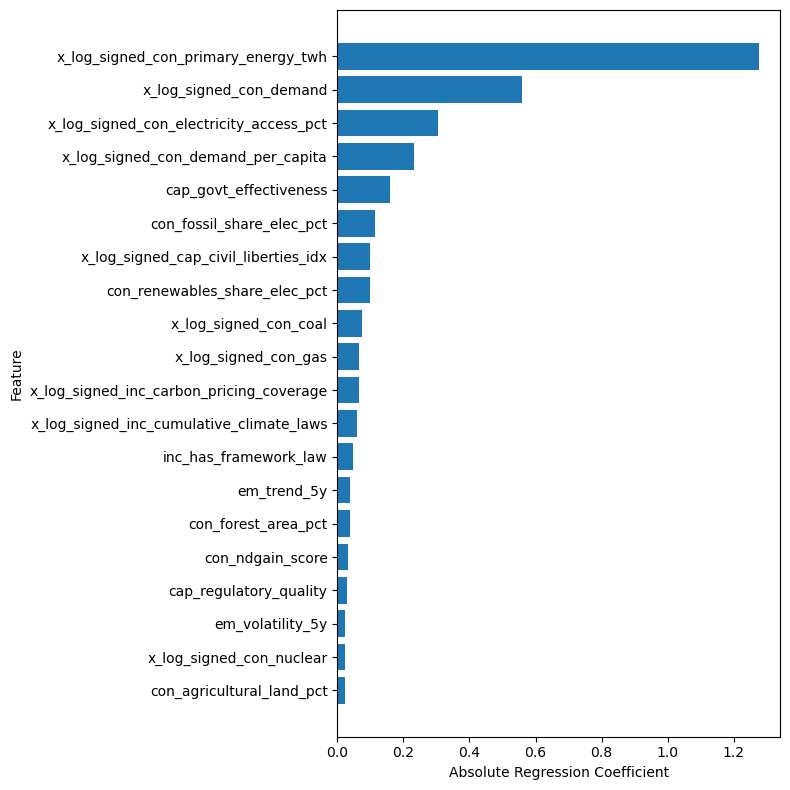

In [63]:
ra_4.plot_top_enet_regressors()

In [64]:
# one model
ra_4.get_model_hyperparameters("ElasticNet")

{'ElasticNet': {'is_fitted': True,
  'hyperparameters': {'alphas': 'warn',
   'copy_X': True,
   'cv': TimeSeriesSplit(gap=0, max_train_size=None, n_splits=7, test_size=None),
   'eps': 0.0001,
   'fit_intercept': True,
   'l1_ratio': [0.01],
   'max_iter': 30000,
   'n_alphas': 300,
   'n_jobs': 1,
   'positive': False,
   'precompute': 'auto',
   'random_state': 42,
   'selection': 'cyclic',
   'tol': 0.0001,
   'verbose': 0},
  'selected_alpha': 0.01567120336979496,
  'selected_l1_ratio': 0.01,
  'n_iter': 115}}

In [65]:
# df_l1 = ra_4.enet_l1_ratio_experiment(
#     l1_ratios=[0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95],
#     plot=True,
# )
# df_l1

### Save model

In [66]:
# obtain timestamp
timestamp = int(time.time())

In [67]:
# --------------------------------------------------
# Save the training data with predictions
# --------------------------------------------------
training_df_after_ablation.to_csv(
    os.path.join(TRAINING_DIR_PATH, f"training_df_{timestamp}.csv"),
    index=False
)

# --------------------------------------------------
# Select trained pipelines to save
# --------------------------------------------------
trained_pipelines = {
    "enet": ra_4.pipe_enet,   # <- THIS is the key line
}

rewrite_existing_models = False

# --------------------------------------------------
# Save pipelines
# --------------------------------------------------
for name, pipeline in trained_pipelines.items():
    model_file_name = f"{name}_pipeline_{timestamp}.pkl"
    model_path = os.path.join(MODELS_DIR_PATH, model_file_name)

    if os.path.exists(model_path) and not rewrite_existing_models:
        print(f"Model {model_file_name} already exists. Skipping save.")
        continue

    if os.path.exists(model_path):
        print(f"Overwriting existing model at {model_path}")
    else:
        print(f"Saving model to {model_path}")

    joblib.dump(pipeline, model_path)

Saving model to /Users/tony/Documents/research_project/etpe_project/ml_scripts/output/models/enet_pipeline_1775599514.pkl
